# 使用完全連接層估算簡單線性迴歸的參數w、b

In [1]:
# 載入套件
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from sklearn.linear_model import LinearRegression

## 產生隨機資料

In [2]:
# 產生線性隨機資料100筆，介於 0-50
n = 100
X = np.linspace(0, 50, n)
y = np.linspace(0, 50, n)

# 資料加一點雜訊(noise)
X += np.random.uniform(-10, 10, n)
y += np.random.uniform(-10, 10, n)

## 定義模型

In [3]:
# 定義模型
def create_model(input_feature: int, output_feature: int):
    model = nn.Sequential(
        nn.Linear(input_feature, output_feature),
        nn.Flatten(0, -1), # 所有維度轉成一維 
    )
    return model

In [4]:
# 測試扁平層(Flatten)
input = torch.randn(32, 1, 5, 5)
m = nn.Sequential(
    nn.Conv2d(1, 32, 5, 1, 1),
    nn.Flatten(),
)
output: torch.Tensor = m(input)
output.size()

torch.Size([32, 288])

## 定義訓練函數

In [5]:
def train(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 2_000,
    lr: float = 1e-6,
):
    model = create_model(1, 1)

    # 定義損失函數
    loss_fn = nn.MSELoss(reduction='sum')

    loss_list: list[float] = []
    w_list: list[float] = []
    b_list: list[float] = []
    for epoch in range(epochs):  # 執行訓練週期
        y_pred: torch.Tensor = model(X)  # 預測值

        # 計算損失函數值
        # print(y_pred.shape, y.shape)
        MSE = loss_fn.forward(y_pred, y)

        # 梯度重置：改由model.zero_grad() 取代 w、b 逐一設定。
        model.zero_grad()

        # 反向傳導
        MSE.backward()

        # 權重更新：改用 model.parameters 取代 w、b 逐一更新
        with torch.no_grad():
            for param in model.parameters():
                assert param.grad is not None
                param -= lr * param.grad

        # 記錄訓練結果
        linear_layer = cast(nn.Linear, model[0])
        if (epoch + 1) % 1000 == 0 or epochs < 1000:
            w_list.append(linear_layer.weight[:, 0].item())  # w.item()：轉成常數
            b_list.append(linear_layer.bias.item())
            loss_list.append(MSE.item())

    return w_list, b_list, loss_list

## 執行訓練

In [6]:
# 執行訓練
X2, y2 = torch.FloatTensor(X.reshape(X.shape[0], 1)), torch.FloatTensor(y)
w_list, b_list, loss_list = train(X2, y2)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.9180669188499451, b=0.9743688106536865


In [7]:
# 使用不同學習率及更多的執行週期訓練
X2, y2 = torch.FloatTensor(X.reshape(X.shape[0], 1)), torch.FloatTensor(y)
w_list, b_list, loss_list = train(X2, y2, epochs=10**5, lr=1e-5)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.8604049682617188, b=3.029900550842285


In [8]:
# 執行訓練
coef = np.polyfit(X, y, deg=1)

# 取得 w、b 的最佳解
print(f'w={coef[0]}, b={coef[1]}')

w=0.8603990335892744, b=3.030111958390892


In [9]:
X2 = X.reshape(X.shape[0], 1)

lr = LinearRegression()
lr.fit(X2, y)

lr.coef_[0], lr.intercept_

(np.float64(0.860399033589275), np.float64(3.030111958390883))

## 顯示迴歸線

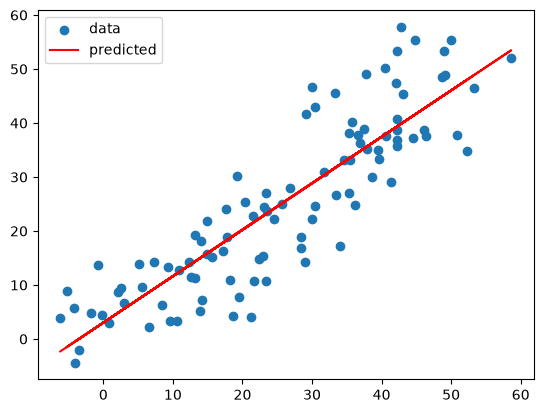

In [10]:
plt.scatter(X, y, label='data')
plt.plot(X, w_list[-1] * X + b_list[-1], 'r-', label='predicted')
plt.legend()

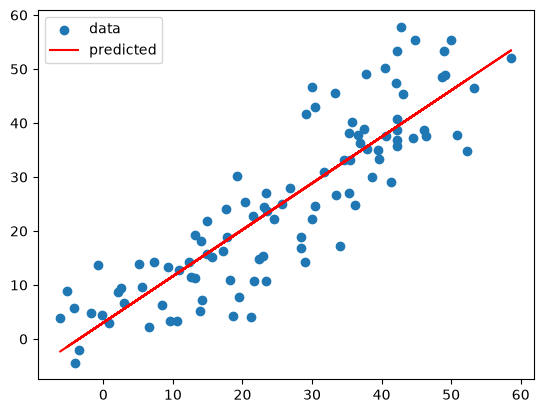

In [11]:
# NumPy 求得的迴歸線
plt.scatter(X, y, label='data')
plt.plot(X, coef[0] * X + coef[1], 'r-', label='predicted')
plt.legend()

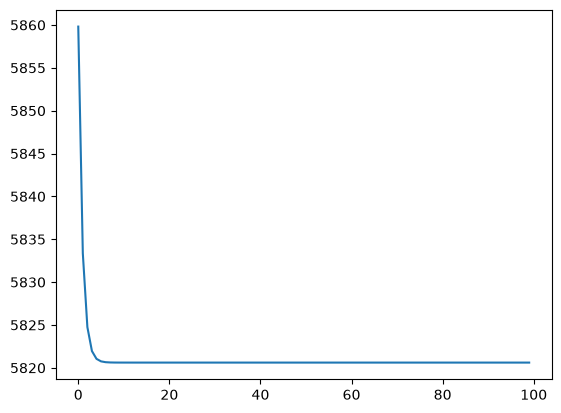

In [12]:
# 損失函數繪圖
plt.plot(loss_list)

In [13]:
loss_list

[5859.8154296875,
 5833.35009765625,
 5824.75048828125,
 5821.95654296875,
 5821.04833984375,
 5820.75341796875,
 5820.65771484375,
 5820.626953125,
 5820.6162109375,
 5820.61328125,
 5820.6123046875,
 5820.61181640625,
 5820.611328125,
 5820.611328125,
 5820.611328125,
 5820.611328125,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.61083984375,
 5820.610

In [14]:
w_list

[0.893503725528717,
 0.8792695999145508,
 0.8711556792259216,
 0.8665305972099304,
 0.8638941049575806,
 0.862391471862793,
 0.8615346550941467,
 0.8610463738441467,
 0.8607680797576904,
 0.8606094121932983,
 0.8605190515518188,
 0.8604673743247986,
 0.8604382276535034,
 0.8604216575622559,
 0.8604125380516052,
 0.8604058623313904,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.8604049682617188,
 0.860404968261

In [15]:
b_list

[1.8499938249588013,
 2.357415199279785,
 2.6466586589813232,
 2.811537027359009,
 2.9055192470550537,
 2.959090232849121,
 2.9896278381347656,
 3.007035970687866,
 3.0169572830200195,
 3.022613525390625,
 3.0258352756500244,
 3.0276715755462646,
 3.028716564178467,
 3.0293052196502686,
 3.029629707336426,
 3.0298681259155273,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.029900550842285,
 3.02990055